<a href="https://colab.research.google.com/github/PhoebeJS/casa0018/blob/main/Week3/CASA0018_3_2_MNISTCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST CNN
In this example we are still using the same MNIST dataset but this time we will be using Convolutions to try and improve the accuracy of our model.

Information on the NMIST character dataset can be found [here](http://yann.lecun.com/exdb/mnist/).

# Importing dependencies
Let's start by importing TensorFlow, printing out the version number and create an object that points to the MNIST data via the tf.keras datasets API. How did we know where the dataset was? TensorFlow Datasets provide a list of resources that are easily accessible in the Colabs - a catalogue of what is availabe is at: https://www.tensorflow.org/datasets/catalog/overview)


In [ ]:
import tensorflow as tf
print(tf.__version__)
mnist = tf.keras.datasets.mnist

2.19.0



# Loading the image data
Calling **load_data** on the **mnist** object will give you two sets of lists, these will be the training and testing values for the graphics that contain the clothing items and their labels.


In [ ]:
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Exploring the data and preparing it for use
What does these values look like? We are going to import a library that helps us display an image and point it to a training image, and a training label to see. Experiment with different indices in the array.


shape: (28, 28)
Label: 0


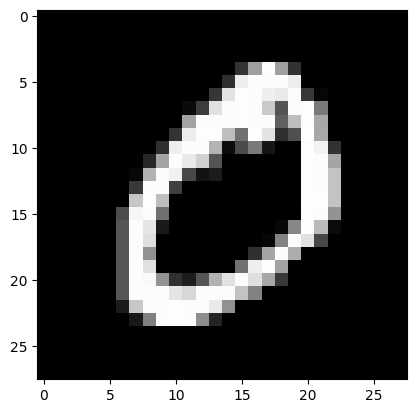

In [ ]:
sample = 1;
print("shape:", training_images[sample].shape)

import matplotlib.pyplot as plt
plt.imshow(training_images[sample], cmap='gray')
print("Label:", training_labels[sample])


Each of the 'pixel' values above are between 0 (black) and 255 (white).

As before, we '**normalize**' the data between 0 and 1 in the same way, ie in Python we just need to divide all values by 255.0:

In [ ]:
training_images=training_images / 255.0
test_images=test_images/255.0

# Building the model
To create the sequence of layers in a model we use  '**Sequential**'. The model has 7 layers with the first 4 being a mix of convlution and pooling.

We use **Conv2d** to specify a convolution layer and assign **64 convolutions** of size **3x3**, we use a
'**relu**' (Rectified Linear Unit - ReLU) activation function which converts any negative value to zero (to keep us between 0 and 1) and define the input shape to be 28x28 pixels with 1 colour depth).

In the second layer we use **MaxPooling** to define a pooling layer which compresses the image while maintaining features. By specifying a size **2x2** we are effectively quartering the size of the image.

We then repeat the same pattern again for layers 3 and 4.

The remaining layers are the same as the previous model architecture. Layer 5 is called '**Flatten**' which takes the previous layer and turns it into a 1 dimensional set. The 6th layer '**Dense**' has 128 neurons and also uses '**relu**' and the 7th layer '**Dense**' has 10 neurons which relate to the 10 MNIST categories. It implements a '**softmax**' activition function which looks at all the probabilities in that layer of neurons and sets the highest value to 1 and all the others to 0 - this makes it programatically easier to find the most likely solution.  

Finally we output a model summary - note how many parameters this model creates compared to ones built so far.

In [ ]:
# Big question: why? what is overall purpose? Layers are first extracting features through filters (convolutions),
# then pooling to compress that image, reducing amount of info
# Does this mean that we get smaller and smaller amounts of pixel size/info? Is there a limit to reduction where you may reduce too much?
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

# Some answers to my above thoughts:
# You’re compressing where information lives while expanding what information is represented. So we are shrinking spatial size but
# increasing the number of features and parameters

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# A breakdown of the code above (code stays exactly the same, is just heavily annotated)
model = tf.keras.models.Sequential([

    # INPUT
    # Receives a 28x28 grayscale image
    # Shape: (28, 28, 1)
    tf.keras.layers.Conv2D(
        64, (3,3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    # Applies 64 different 3x3 filters to the image
    # Learns low-level features (edges, corners, textures)
    # Output shape (no padding): (26, 26, 64)
    # Spatial size shrinks slightly, depth (feature maps) increases

    tf.keras.layers.MaxPooling2D(2, 2),
    # Downsamples each feature map by taking the max over 2x2 regions
    # Keeps strongest feature responses, discards precise location
    # Output shape: (13, 13, 64)
    # Spatial compression → translation invariance

    tf.keras.layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),
    # Applies new filters to feature maps, not raw pixels
    # Learns higher-level patterns (combinations of edges/shapes)
    # Output shape: (11, 11, 64)
    # Representation becomes more abstract, spatial size shrinks again

    tf.keras.layers.MaxPooling2D(2,2),
    # Further spatial compression
    # Output shape: (5, 5, 64)
    # Information is now compact but semantically rich

    tf.keras.layers.Flatten(),
    # Converts 3D feature maps into a 1D vector
    # (5 * 5 * 64 = 1600)
    # No learning here — just reshaping for dense layers

    tf.keras.layers.Dense(128, activation='relu'),
    # Fully connected layer
    # Learns global combinations of extracted features
    # Most of the model's parameters live here

    tf.keras.layers.Dense(10, activation='softmax')
    # Output layer
    # Produces probabilities over 10 classes
])


---

#### NB on output size
In the above we see through convolutions and pooling we go from at the start an input shape of 28, 28 to 26, 26 (and later through pooling, 13, 13, etc). The reason for this is the general rule for convolution output size which says that for one spatial dimension (height or width), output size equals

(N - F + 2P) / (S) + 1

Where,
*   N = input size
*   F = filter (kernel size)
*   P = padding
* S = stride

This is separately applied to height & width.

If we see this in ex with the first layer (note, in default Keras, S = 1, P = 0 or valid, and F = 3), the equation would go

(28-3 + 0) / (1) = 26

So (28, 28) -> (26, 26). 64 stays the same because there are 64 filters.

If we had written 'padding = 'same'', then Keras would choose padding so the output size = the input size. So (28, 28) -> (28, 28).

Pooling has the same logic but no padding included in its equation. So the specification (2, 2), goes in as

(26 - 2) / 2 + 1 = 13

resulting in (26, 26) going to (13, 13).

---



After defining the model we build it by compiling with an optimizer and loss function and then train it by calling **model.fit** to fit your training data to your training labels.

In [ ]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9153 - loss: 0.2715
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9866 - loss: 0.0425
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9911 - loss: 0.0268
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9933 - loss: 0.0201
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9957 - loss: 0.0128


The accuracy value at the end of the final epoch is about 0.99 or about 99% accurate in classifying the training data. I.E., it figured out a pattern match between the image and the labels that worked 99% of the time. Whilst each epoch takes longer to run, this model is more accurate than the previous without the convolutions.

Next we can call '**model.evaluate**', and pass in the test data, and it will report back the loss for each. Let's give it a try:

In [ ]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9882 - loss: 0.0361


[0.028803855180740356, 0.9904000163078308]

For me, that returned a accuracy of about .9895, which means it was about 98.95% accurate. As expected it probably would not do as well with *unseen* data as it did with data it was trained on!  

# Extras

If you want to dig deeper into finding out were errors or misclassifications are coming from take a look at **TensorBoard**. It provides a useful tool to check your model results and it makes really useful visualisations for sharing your results.

The example below shows a quick way of "seeing" a confusion matrix of the results.


In [ ]:
import numpy as np
test_predictions = np.argmax(model.predict(test_images),axis=-1)
#test_predictions = model.predict_classes(test_images) - deprecated in TF 2.6
result = tf.math.confusion_matrix(test_labels, test_predictions)
print(result)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
tf.Tensor(
[[ 972    0    0    0    1    0    1    1    2    3]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   1    0 1020    2    0    0    0    5    4    0]
 [   0    0    2 1006    0    1    0    0    1    0]
 [   0    0    1    0  963    0    4    0    1   13]
 [   0    0    1    6    0  879    1    0    1    4]
 [   2    4    1    0    2    2  943    0    4    0]
 [   0    4    2    0    0    0    0 1018    1    3]
 [   2    0    1    1    0    1    0    1  965    3]
 [   0    0    0    0    3    0    0    0    3 1003]], shape=(10, 10), dtype=int32)


To see how you can visualise this in TensorBoard take a look at these two links:


1.   [Intro to TensorBoard](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/get_started.ipynb#scrollTo=-Iue509kgOyE)
2.   [Displaying image data in TensorBoard](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/image_summaries.ipynb)
